# EEE408 – Artificial Intelligence II  
## Coursework 1: Predicting Prevalent Diabetes Using the TUDA Dataset

This notebook follows the CRISP-DM methodology to build and compare machine learning classifiers 
that predict the presence of diabetes in participants of the TUDA Ageing Cohort Study.

---
### 1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, balanced_accuracy_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.inspection import permutation_importance
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Reproducibility seed
SEED = 42
np.random.seed(SEED)

# Plotting style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

print("All libraries loaded successfully.")

All libraries loaded successfully.


---
### 2. Load Dataset

The TUDA (Trinity, University of Ulster and Department of Agriculture) dataset contains health 
records for approximately 5,000 older adults in Northern Ireland and the Republic of Ireland.  
The CSV file is loaded and its basic properties are inspected.

In [3]:
df_raw = pd.read_csv("../data/TUDA-Reduced.csv")
print(f"Dataset shape: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")
df_raw.head(3)

Dataset shape: 5186 rows × 104 columns


,ProjectIDnumber,Cohort,Daterecordcreated,Gender,Deciage,Waistmeasurementincm,Hipmeasurementincm,WaistHip,Timedupngo,Bornwherecat,...,Vitamin_D,tHcyumolL,HoloTCpmolL,TotalserumB12pmolL,MMAumolL,FolatenmolL,RCFnmolL,VitaminB6markerPLPnmolL,RiboflavinmarkerEGRac,TotalRBANSscale
0,1,Cognitive,17/12/2008,Male,80.726027,91.0,103.0,0.883495,24.5,Island of Ireland,...,52.2,25.40,44.20,191.9,0.391,8.29,573.70,8.80,1.66,65.0
1,2,Cognitive,17/12/2008,Male,74.547945,106.0,110.0,0.963636,19.5,Island of Ireland,...,58.3,20.10,49.29,366.6,0.350,13.43,664.46,42.69,1.51,79.0
2,3,Cognitive,19/12/2008,Female,70.457534,109.0,153.0,0.712418,21.5,Island of Ireland,...,14.9,14.21,65.53,361.1,0.151,13.43,798.52,36.33,1.44,105.0


---
### 3. Initial Data Exploration

Before any transformations, the dataset is explored to understand data types, 
value ranges, and the extent of missing values.

In [4]:
# Data types and non-null counts
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 5186 entries, 0 to 5185
Columns: 104 entries, ProjectIDnumber to TotalRBANSscale
dtypes: float64(74), int64(1), str(29)
memory usage: 4.1 MB


In [5]:
# Descriptive statistics for numeric columns
df_raw.describe().round(2)

,ProjectIDnumber,Deciage,Waistmeasurementincm,Hipmeasurementincm,WaistHip,Timedupngo,Weightinkg,Heightincm,Bodymassindex,AverageSystolic,...,Vitamin_D,tHcyumolL,HoloTCpmolL,TotalserumB12pmolL,MMAumolL,FolatenmolL,RCFnmolL,VitaminB6markerPLPnmolL,RiboflavinmarkerEGRac,TotalRBANSscale
count,5186.00,5186.00,5111.00,5108.00,5108.00,4963.00,5165.00,5159.00,5158.00,5181.00,...,5171.00,5173.00,5125.00,5103.00,1514.00,5139.00,4881.00,5176.00,5173.00,4961.00
mean,2993.57,74.03,95.22,104.59,0.91,14.04,72.97,161.40,27.90,144.43,...,59.12,14.84,70.77,289.32,0.47,45.19,1099.84,77.29,1.34,85.45
std,1825.65,8.27,14.10,10.98,0.08,9.18,16.86,9.65,5.39,21.14,...,31.32,5.79,60.52,207.18,0.51,81.04,623.46,66.53,0.21,16.97
min,1.00,59.72,48.00,52.00,0.40,3.00,31.00,114.00,13.12,76.00,...,1.54,6.26,2.41,18.80,0.09,2.73,12.28,4.15,1.01,11.00
25%,1298.25,67.15,86.00,98.00,0.85,8.00,61.00,154.10,24.35,129.50,...,34.00,11.09,42.39,193.05,0.24,16.42,676.20,39.66,1.21,74.00
50%,2896.50,73.41,95.00,104.00,0.91,10.40,71.00,160.00,27.41,143.00,...,54.50,13.46,59.39,262.40,0.34,26.20,947.75,61.33,1.30,85.00
75%,4700.75,80.21,104.00,110.00,0.96,18.00,83.00,168.00,30.86,157.50,...,80.50,16.97,81.99,350.85,0.51,46.23,1395.10,91.97,1.42,97.00
max,6000.00,101.99,191.00,158.00,1.46,140.00,154.60,195.00,60.60,237.00,...,288.00,72.66,1216.90,9003.60,10.34,1399.91,10211.07,852.50,3.77,145.00


In [6]:
# Missing value summary
missing = df_raw.isnull().mean().sort_values(ascending=False) * 100
print("Columns with missing data (%):")
print(missing[missing > 0].round(2).to_string())

Columns with missing data (%):
MMAumolL                            70.81
Averageperdaysmoked                 59.26
Whatagestoppedsmoking               59.16
Howmanydaysforrolloftobacco         52.99
Agestartedsmoking                   47.36
Stillasmoker                        47.11
Smokedcigarettesregularly           46.53
Supplementnameverification          43.46
Numberofcigarettesperday            41.55
RCFnmolL                             5.88
TotalRBANSscale                      4.34
Timedupngo                           4.30
MMSETotal                            4.28
HbA1C                                3.30
LDL                                  2.76
CRP                                  2.70
GFRmlmin                             2.24
TotalIADL                            1.85
Takingownmedicine                    1.70
TotalserumB12pmolL                   1.60
Glucose                              1.50
Hipmeasurementincm                   1.50
WaistHip                             1.50
Wai

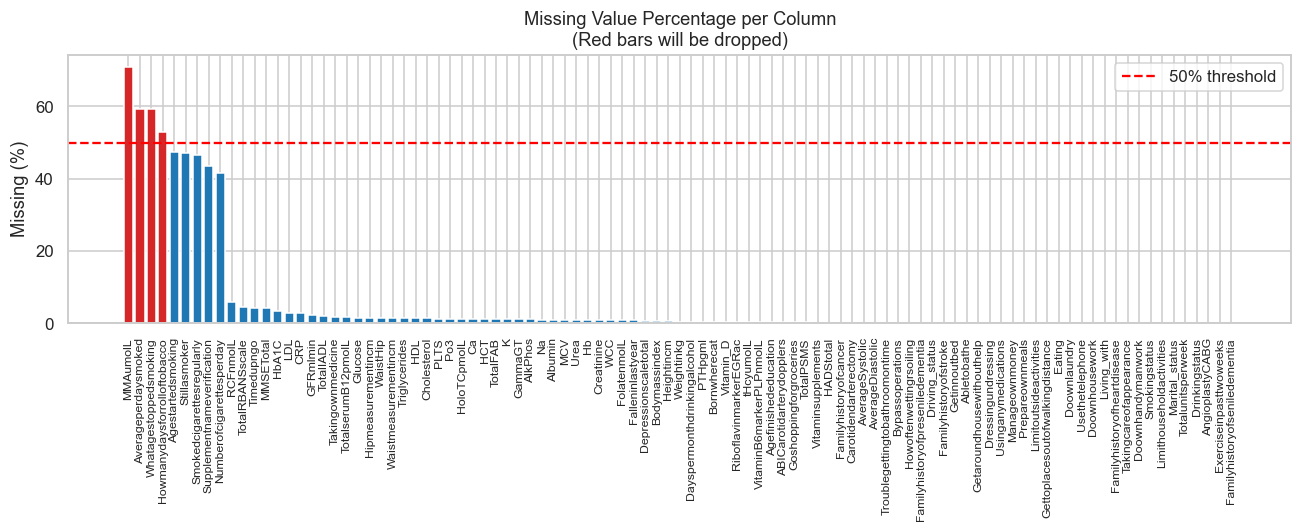

In [7]:
# Visualise missing value proportions
fig, ax = plt.subplots(figsize=(12, 5))
missing_plot = missing[missing > 0]
bars = ax.bar(range(len(missing_plot)), missing_plot.values,
              color=["#d62728" if v > 50 else "#1f77b4" for v in missing_plot.values])
ax.axhline(50, color="red", linestyle="--", label="50% threshold")
ax.set_xticks(range(len(missing_plot)))
ax.set_xticklabels(missing_plot.index, rotation=90, fontsize=8)
ax.set_ylabel("Missing (%)")
ax.set_title("Missing Value Percentage per Column\n(Red bars will be dropped)")
ax.legend()
plt.tight_layout()
plt.show()

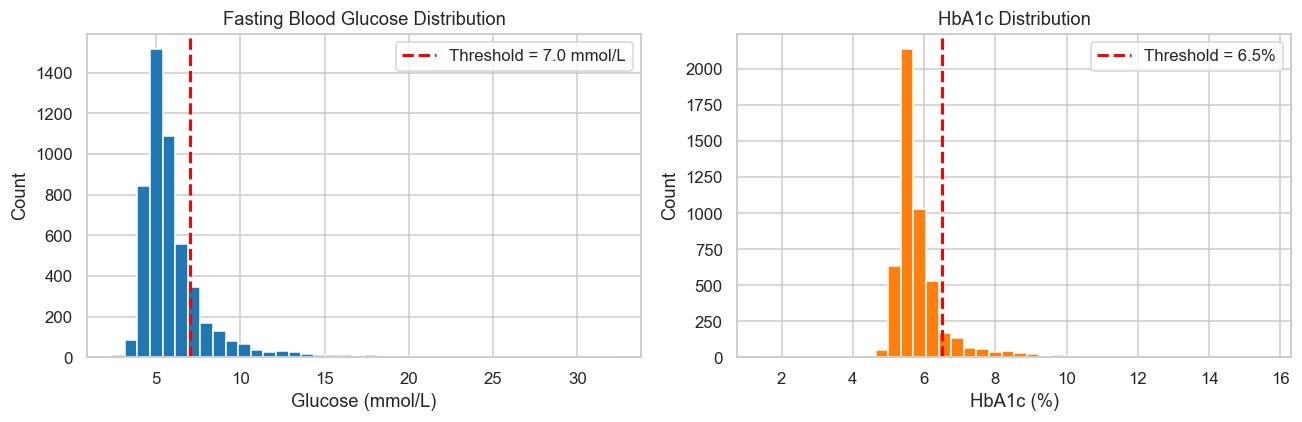

In [8]:
# Distribution of key clinical variables
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_raw["Glucose"].dropna(), bins=40, color="#1f77b4", edgecolor="white")
axes[0].axvline(7.0, color="red", linestyle="--", linewidth=2, label="Threshold = 7.0 mmol/L")
axes[0].set_title("Fasting Blood Glucose Distribution")
axes[0].set_xlabel("Glucose (mmol/L)")
axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].hist(df_raw["HbA1C"].dropna(), bins=40, color="#ff7f0e", edgecolor="white")
axes[1].axvline(6.5, color="red", linestyle="--", linewidth=2, label="Threshold = 6.5%")
axes[1].set_title("HbA1c Distribution")
axes[1].set_xlabel("HbA1c (%)")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()

---
### 4. Create Target Variable (DiabetesFlag)

A binary target variable **DiabetesFlag** is derived using clinical diagnostic criteria:

| Criterion | Threshold |
|-----------|-----------|
| Fasting Blood Glucose | ≥ 7.0 mmol/L |
| HbA1c | ≥ 6.5% |

If **either** condition is met the participant is labelled as diabetic (`DiabetesFlag = 1`).

> **Important:** Glucose and HbA1C are immediately removed after constructing the target to prevent **target leakage** — these variables directly define the label and must never appear as model features.

In [9]:
df = df_raw.copy()

# Create binary target from clinical thresholds
df["DiabetesFlag"] = ((df["Glucose"] >= 7.0) | (df["HbA1C"] >= 6.5)).astype(int)

# Confirm target was created correctly
print("DiabetesFlag value counts:")
print(df["DiabetesFlag"].value_counts())
print()
print(f"Diabetes prevalence: {df['DiabetesFlag'].mean()*100:.1f}%")

# Remove leakage columns immediately
df = df.drop(columns=["Glucose", "HbA1C"])

# Confirm removal
assert "Glucose" not in df.columns, "Leakage: Glucose still present!"
assert "HbA1C"   not in df.columns, "Leakage: HbA1C still present!"
print("\nGlucose and HbA1C successfully removed.")

DiabetesFlag value counts:
DiabetesFlag
0    4037
1    1149
Name: count, dtype: int64

Diabetes prevalence: 22.2%

Glucose and HbA1C successfully removed.


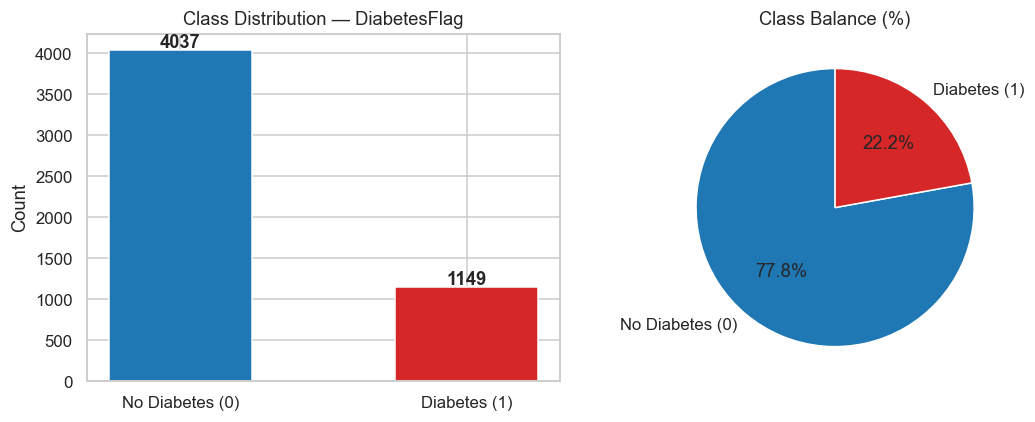


Class imbalance ratio: 3.5:1  →  SMOTE will be used during training.


In [10]:
# Visualise class balance
counts = df["DiabetesFlag"].value_counts()
labels = ["No Diabetes (0)", "Diabetes (1)"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(labels, counts.values, color=["#1f77b4", "#d62728"], width=0.5)
axes[0].set_ylabel("Count")
axes[0].set_title("Class Distribution — DiabetesFlag")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha="center", fontweight="bold")

axes[1].pie(counts.values, labels=labels, autopct="%1.1f%%",
            colors=["#1f77b4", "#d62728"], startangle=90)
axes[1].set_title("Class Balance (%)")

plt.tight_layout()
plt.show()
print(f"\nClass imbalance ratio: {counts[0]/counts[1]:.1f}:1  →  SMOTE will be used during training.")

---
### 5. Data Cleaning

Data cleaning involves:
1. **Removing non-predictive identifiers** (`ProjectIDnumber`, `Daterecordcreated`)
2. **Dropping high-missingness columns** (>50% missing)
3. **Outlier detection** using IQR on key numeric features

In [11]:
# 5a. Remove non-predictive columns
drop_ids = ["ProjectIDnumber", "Daterecordcreated"]
df = df.drop(columns=[c for c in drop_ids if c in df.columns])
print(f"Removed identifier columns. Shape: {df.shape}")

Removed identifier columns. Shape: (5186, 101)


In [12]:
# 5b. Drop columns with more than 50% missing values
missing_rate = df.isnull().mean()
high_missing = missing_rate[missing_rate > 0.50].index.tolist()

print(f"Columns with >50% missing values ({len(high_missing)} columns):")
for c in high_missing:
    print(f"  {c:40s}  {missing_rate[c]*100:.1f}%")

df = df.drop(columns=high_missing)
print(f"\nShape after dropping high-missing columns: {df.shape}")

Columns with >50% missing values (4 columns):
  Howmanydaysforrolloftobacco               53.0%
  Whatagestoppedsmoking                     59.2%
  Averageperdaysmoked                       59.3%
  MMAumolL                                  70.8%

Shape after dropping high-missing columns: (5186, 97)


In [13]:
# 5c. Outlier detection using IQR on numeric columns
num_cols_check = df.select_dtypes(include=np.number).columns.drop("DiabetesFlag")

outlier_summary = []
for col in num_cols_check:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 3*IQR) | (df[col] > Q3 + 3*IQR)).sum()
    if n_out > 0:
        outlier_summary.append({"Feature": col, "Outliers (extreme)": n_out,
                                 "% of rows": round(n_out/len(df)*100, 2)})

outlier_df = pd.DataFrame(outlier_summary).sort_values("Outliers (extreme)", ascending=False)
print("Features with extreme outliers (3×IQR rule):")
print(outlier_df.to_string(index=False))
print("\nNote: Outliers are retained — the imputation pipeline uses median imputation")
print("which is robust to extreme values in medical data.")

Features with extreme outliers (3×IQR rule):
                       Feature  Outliers (extreme)  % of rows
             Takingownmedicine                 986      19.01
Troublegettingtobathroomontime                 975      18.80
                   Abletobathe                 942      18.16
       Howoftenwettingrsoiling                 815      15.72
     Getaroundhousewithouthelp                 755      14.56
                Manageownmoney                 598      11.53
      Numberofcigarettesperday                 595      11.47
                  Getinnoutbed                 370       7.13
            Dressingundressing                 341       6.58
             Totalunitsperweek                 288       5.55
                       GammaGT                 222       4.28
        Takingcareofappearance                 194       3.74
                   HoloTCpmolL                 170       3.28
                   FolatenmolL                 154       2.97
       VitaminB6markerPLP

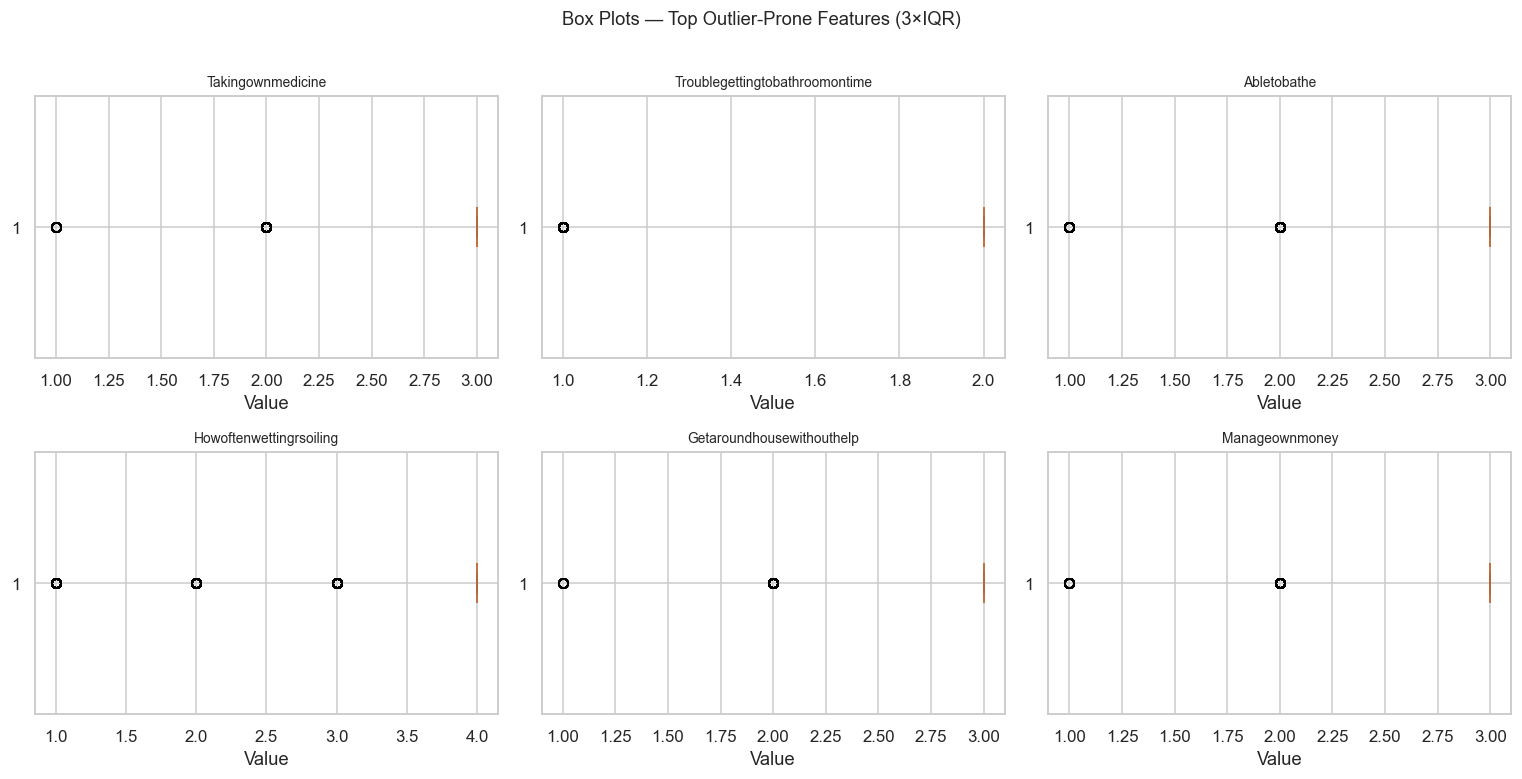

In [14]:
# 5d. Visualise outlier-heavy features
top_outlier_cols = outlier_df.head(6)["Feature"].tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, col in enumerate(top_outlier_cols):
    axes[i].boxplot(df[col].dropna(), vert=False, patch_artist=True,
                    boxprops=dict(facecolor="#aec6e8"))
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("Value")

plt.suptitle("Box Plots — Top Outlier-Prone Features (3×IQR)", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

---
### 6. Data Analysis and Dimensionality Reduction

#### 6a. Correlation Analysis  
A Pearson correlation heatmap is computed for numeric features to identify highly correlated 
pairs that may add redundancy.

#### 6b. Feature–Target Correlation  
The top features most correlated with DiabetesFlag are identified.

#### 6c. PCA  
Principal Component Analysis is applied after scaling to reduce the feature space while 
retaining ≥95% of variance. This also removes multicollinearity.

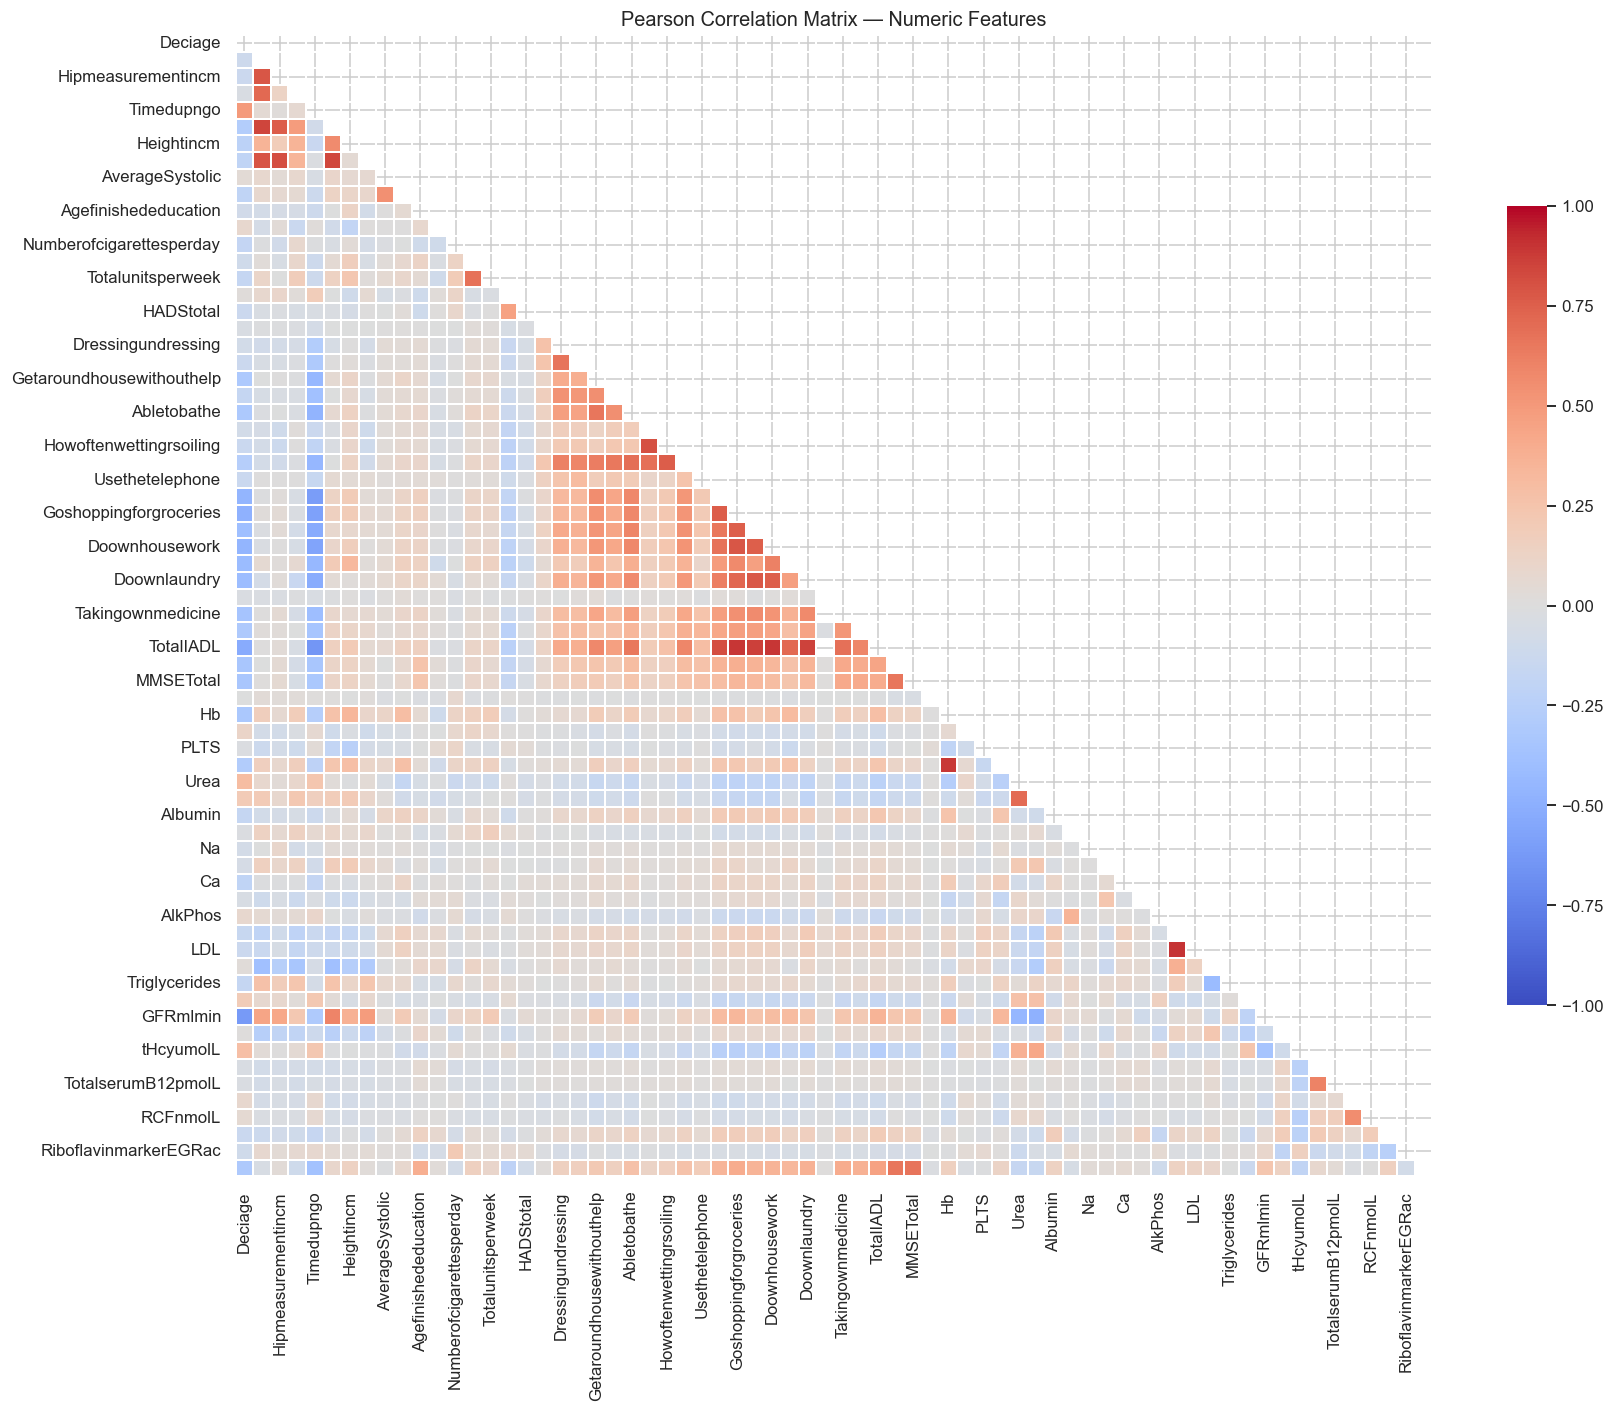

In [15]:
# 6a. Correlation heatmap (numeric features only)
num_df = df.select_dtypes(include=np.number).drop(columns=["DiabetesFlag"])

corr_matrix = num_df.corr()

# Plot only the upper triangle for readability
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(corr_matrix, mask=mask, cmap="coolwarm", center=0,
            vmin=-1, vmax=1, linewidths=0.3, ax=ax, cbar_kws={"shrink": 0.7})
ax.set_title("Pearson Correlation Matrix — Numeric Features", fontsize=13)
plt.tight_layout()
plt.show()

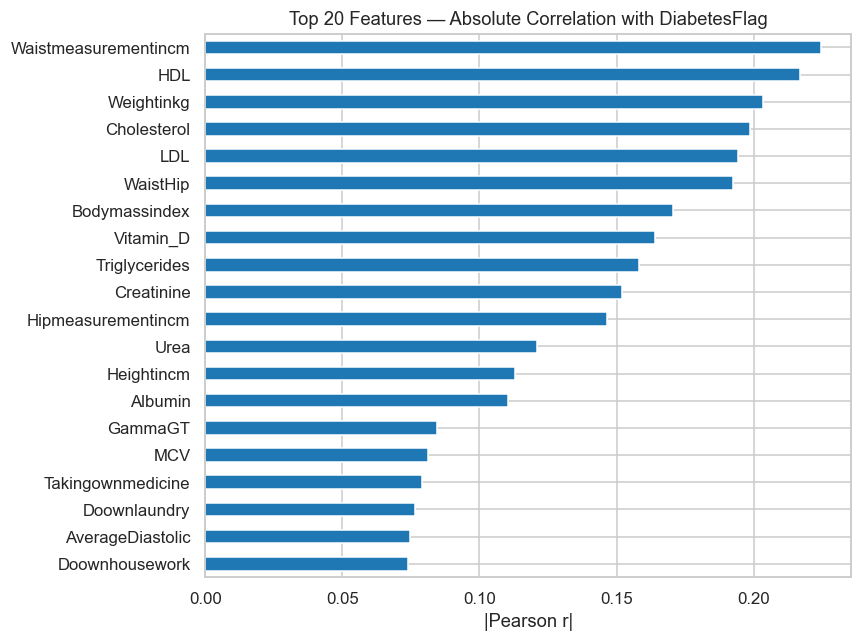

Top 10 features correlated with DiabetesFlag:
Waistmeasurementincm    0.2243
HDL                     0.2169
Weightinkg              0.2034
Cholesterol             0.1985
LDL                     0.1944
WaistHip                0.1923
Bodymassindex           0.1705
Vitamin_D               0.1639
Triglycerides           0.1582
Creatinine              0.1520


In [16]:
# 6b. Feature–target point-biserial correlations
target_corr = (
    df.select_dtypes(include=np.number)
      .corr()["DiabetesFlag"]
      .drop("DiabetesFlag")
      .abs()
      .sort_values(ascending=False)
      .head(20)
)

fig, ax = plt.subplots(figsize=(8, 6))
target_corr.sort_values().plot(kind="barh", ax=ax, color="#1f77b4")
ax.set_title("Top 20 Features — Absolute Correlation with DiabetesFlag")
ax.set_xlabel("|Pearson r|")
plt.tight_layout()
plt.show()

print("Top 10 features correlated with DiabetesFlag:")
print(target_corr.head(10).round(4).to_string())

---
### 7. Feature Preprocessing

A `ColumnTransformer` pipeline is built with separate sub-pipelines for numeric and categorical features:

- **Numeric**: Median imputation → Standard scaling  
- **Categorical**: Most-frequent imputation → One-hot encoding  

This approach prevents data leakage by fitting all transformers on training data only.

In [17]:
# Separate features and target
X = df.drop(columns=["DiabetesFlag"])
y = df["DiabetesFlag"]

print(f"Features matrix shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts().to_string()}")

Features matrix shape: (5186, 96)
Target distribution:
DiabetesFlag
0    4037
1    1149


---
### 8. Train / Test Split

An 80/20 stratified split is used to preserve the class ratio in both sets.  
`random_state=42` ensures reproducibility.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f"Training set  : {X_train.shape[0]} samples  "
      f"(Diabetes prevalence: {y_train.mean()*100:.1f}%)")
print(f"Test set      : {X_test.shape[0]} samples  "
      f"(Diabetes prevalence: {y_test.mean()*100:.1f}%)")

Training set  : 4148 samples  (Diabetes prevalence: 22.2%)
Test set      : 1038 samples  (Diabetes prevalence: 22.2%)


In [19]:
# Identify numeric and categorical feature columns for the pipeline
num_features = X_train.select_dtypes(include=np.number).columns.tolist()
cat_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

print(f"Numeric features  : {len(num_features)}")
print(f"Categorical features: {len(cat_features)}")

Numeric features  : 68
Categorical features: 28


In [20]:
# Build preprocessing transformer
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_features),
    ("cat", categorical_transformer, cat_features)
])

print("Preprocessing pipeline built successfully.")

Preprocessing pipeline built successfully.


---
### 9. PCA — Explained Variance Analysis

PCA is applied to the preprocessed training features to understand how many components 
are needed to explain ≥95% of the variance. This informs dimensionality reduction choices.

In [21]:
# Fit preprocessor to training data and transform
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)
print(f"Preprocessed shape: {X_train_prep.shape}")

# Full PCA to inspect explained variance
pca_full = PCA(random_state=SEED)
pca_full.fit(X_train_prep)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n95 = int(np.argmax(cum_var >= 0.95)) + 1
n99 = int(np.argmax(cum_var >= 0.99)) + 1

print(f"Components for 95% variance: {n95}")
print(f"Components for 99% variance: {n99}")
print(f"Total components available : {X_train_prep.shape[1]}")

Preprocessed shape: (4148, 1188)
Components for 95% variance: 71
Components for 99% variance: 100
Total components available : 1188


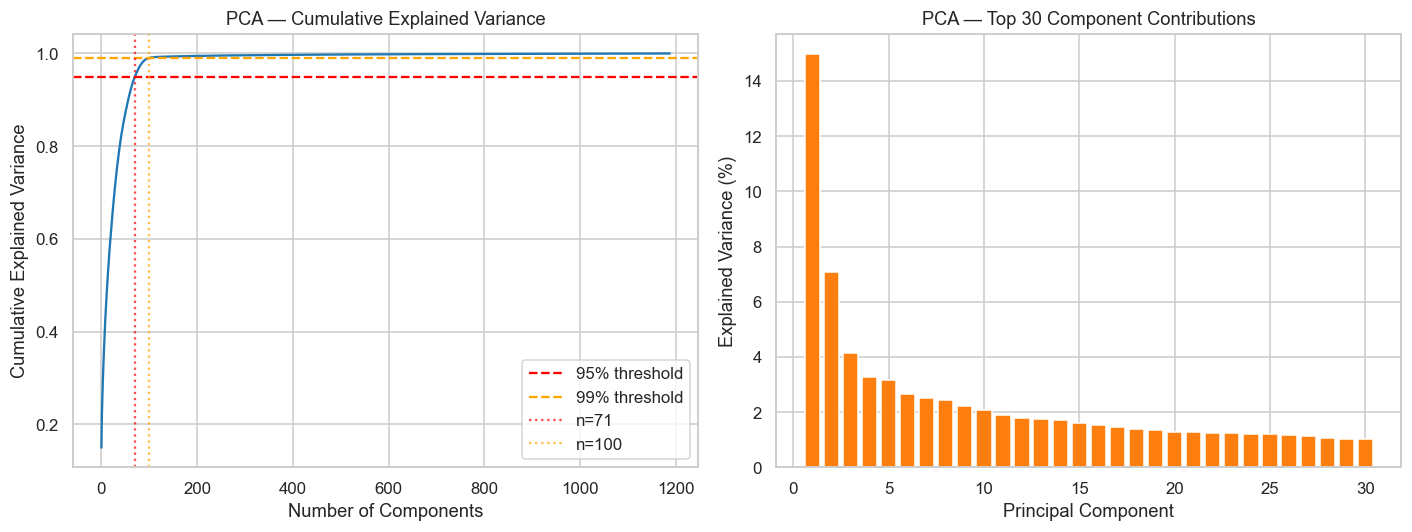

In [22]:
# Plot cumulative explained variance
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Cumulative variance
axes[0].plot(cum_var, color="#1f77b4", linewidth=1.5)
axes[0].axhline(0.95, color="red",    linestyle="--", label="95% threshold")
axes[0].axhline(0.99, color="orange", linestyle="--", label="99% threshold")
axes[0].axvline(n95,  color="red",    linestyle=":",  alpha=0.7, label=f"n={n95}")
axes[0].axvline(n99,  color="orange", linestyle=":",  alpha=0.7, label=f"n={n99}")
axes[0].set_xlabel("Number of Components")
axes[0].set_ylabel("Cumulative Explained Variance")
axes[0].set_title("PCA — Cumulative Explained Variance")
axes[0].legend()

# Individual component variance (first 30)
n_show = min(30, len(pca_full.explained_variance_ratio_))
axes[1].bar(range(1, n_show+1),
            pca_full.explained_variance_ratio_[:n_show] * 100,
            color="#ff7f0e")
axes[1].set_xlabel("Principal Component")
axes[1].set_ylabel("Explained Variance (%)")
axes[1].set_title(f"PCA — Top {n_show} Component Contributions")

plt.tight_layout()
plt.show()

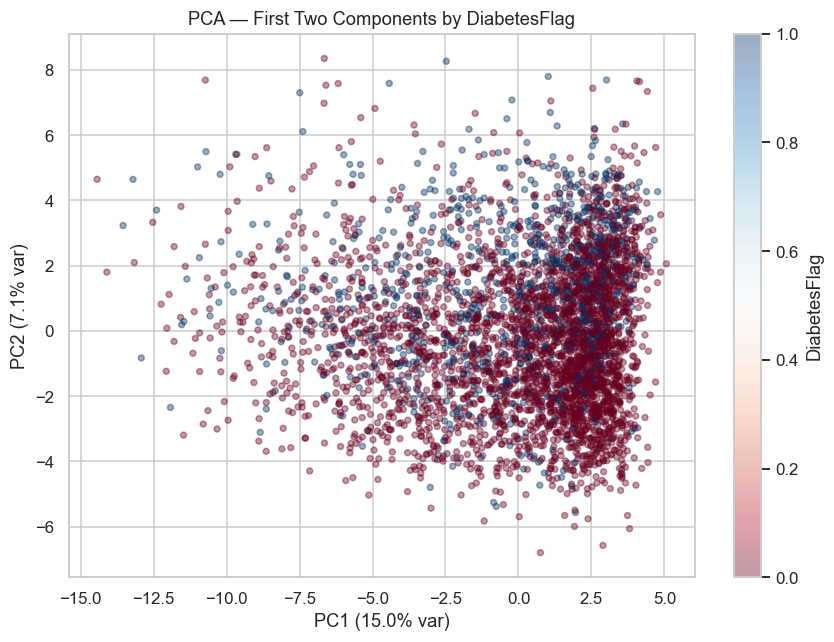

In [23]:
# Visualise first two PCA components coloured by DiabetesFlag
pca_2d = PCA(n_components=2, random_state=SEED)
X_pca_2d = pca_2d.fit_transform(X_train_prep)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                     c=y_train, cmap="RdBu", alpha=0.4, s=15)
plt.colorbar(scatter, ax=ax, label="DiabetesFlag")
ax.set_xlabel(f"PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}% var)")
ax.set_title("PCA — First Two Components by DiabetesFlag")
plt.tight_layout()
plt.show()

---
### 10. Model Training

Three classification models are trained and compared:

| # | Model | Key Characteristics |
|---|-------|---------------------|
| 1 | **Logistic Regression** | Linear baseline, interpretable, fast |
| 2 | **Random Forest** | Non-linear ensemble, handles interactions |
| 3 | **Gradient Boosting** | Sequential ensemble, often top performer |

**Class imbalance handling:** SMOTE (Synthetic Minority Over-sampling Technique) is applied 
inside the training pipeline to balance the training set without contaminating the test set.

**Validation:** 5-fold stratified cross-validation is used for reliable performance estimates.

In [24]:
# Helper function: evaluate a fitted pipeline on the test set
def evaluate_model(name, pipeline, X_te, y_te, threshold=0.5):
    """Return a dict of metrics and print a formatted summary."""
    y_prob = pipeline.predict_proba(X_te)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "Model":              name,
        "Accuracy":           round(accuracy_score(y_te, y_pred), 4),
        "Balanced Acc.":      round(balanced_accuracy_score(y_te, y_pred), 4),
        "Precision":          round(precision_score(y_te, y_pred, zero_division=0), 4),
        "Recall":             round(recall_score(y_te, y_pred, zero_division=0), 4),
        "F1-Score":           round(f1_score(y_te, y_pred, zero_division=0), 4),
        "ROC-AUC":            round(roc_auc_score(y_te, y_prob), 4),
        "PR-AUC":             round(average_precision_score(y_te, y_prob), 4),
    }

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    for k, v in metrics.items():
        if k != "Model":
            print(f"  {k:<20s}: {v}")

    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_te, y_pred)
    print(cm)
    print("\nClassification Report:")
    print(classification_report(y_te, y_pred, digits=4,
                                target_names=["No Diabetes", "Diabetes"]))
    return metrics


results = []  # collect all model result dicts for comparison table

In [25]:
# ── MODEL 1: Logistic Regression ──────────────────────────────────────────
print("Training Model 1: Logistic Regression (with SMOTE)...")

lr_pipe = ImbPipeline(steps=[
    ("prep",  preprocessor),
    ("smote", SMOTE(random_state=SEED)),
    ("model", LogisticRegression(max_iter=2000, random_state=SEED,
                                  class_weight="balanced", C=1.0))
])

lr_pipe.fit(X_train, y_train)

# 5-fold cross-validation on training set
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
lr_cv_f1  = cross_val_score(lr_pipe, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
lr_cv_auc = cross_val_score(lr_pipe, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)

print(f"\nCross-validation F1  : {lr_cv_f1.mean():.4f} (±{lr_cv_f1.std():.4f})")
print(f"Cross-validation AUC : {lr_cv_auc.mean():.4f} (±{lr_cv_auc.std():.4f})")

lr_metrics = evaluate_model("Logistic Regression", lr_pipe, X_test, y_test)
lr_metrics["CV F1 (mean)"] = round(lr_cv_f1.mean(), 4)
lr_metrics["CV AUC (mean)"] = round(lr_cv_auc.mean(), 4)
results.append(lr_metrics)

Training Model 1: Logistic Regression (with SMOTE)...

Cross-validation F1  : 0.4512 (±0.0136)
Cross-validation AUC : 0.7158 (±0.0138)

  Logistic Regression
  Accuracy            : 0.6821
  Balanced Acc.       : 0.6372
  Precision           : 0.3596
  Recall              : 0.5565
  F1-Score            : 0.4369
  ROC-AUC             : 0.6961
  PR-AUC              : 0.3964

Confusion Matrix:
[[580 228]
 [102 128]]

Classification Report:
              precision    recall  f1-score   support

 No Diabetes     0.8504    0.7178    0.7785       808
    Diabetes     0.3596    0.5565    0.4369       230

    accuracy                         0.6821      1038
   macro avg     0.6050    0.6372    0.6077      1038
weighted avg     0.7417    0.6821    0.7028      1038



In [26]:
# ── MODEL 2: Random Forest (with GridSearchCV tuning) ─────────────────────
print("Training Model 2: Random Forest (with SMOTE + GridSearchCV)...")

rf_base = ImbPipeline(steps=[
    ("prep",  preprocessor),
    ("smote", SMOTE(random_state=SEED)),
    ("model", RandomForestClassifier(random_state=SEED, n_jobs=-1))
])

rf_param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth":    [10, 20, None],
    "model__min_samples_leaf": [1, 5],
}

rf_grid = GridSearchCV(
    rf_base,
    param_grid=rf_param_grid,
    scoring="f1",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print(f"\nBest RF params : {rf_grid.best_params_}")
print(f"Best CV F1     : {rf_grid.best_score_:.4f}")

rf_pipe = rf_grid.best_estimator_

rf_cv_f1  = cross_val_score(rf_pipe, X_train, y_train, cv=cv, scoring="f1",      n_jobs=-1)
rf_cv_auc = cross_val_score(rf_pipe, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)

print(f"\nCross-validation F1  : {rf_cv_f1.mean():.4f} (±{rf_cv_f1.std():.4f})")
print(f"Cross-validation AUC : {rf_cv_auc.mean():.4f} (±{rf_cv_auc.std():.4f})")

rf_metrics = evaluate_model("Random Forest (Tuned)", rf_pipe, X_test, y_test)
rf_metrics["CV F1 (mean)"] = round(rf_cv_f1.mean(), 4)
rf_metrics["CV AUC (mean)"] = round(rf_cv_auc.mean(), 4)
results.append(rf_metrics)

Training Model 2: Random Forest (with SMOTE + GridSearchCV)...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best RF params : {'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__n_estimators': 400}
Best CV F1     : 0.3827

Cross-validation F1  : 0.3827 (±0.0196)
Cross-validation AUC : 0.7280 (±0.0072)

  Random Forest (Tuned)
  Accuracy            : 0.7514
  Balanced Acc.       : 0.5931
  Precision           : 0.4176
  Recall              : 0.3087
  F1-Score            : 0.355
  ROC-AUC             : 0.6944
  PR-AUC              : 0.3798

Confusion Matrix:
[[709  99]
 [159  71]]

Classification Report:
              precision    recall  f1-score   support

 No Diabetes     0.8168    0.8775    0.8461       808
    Diabetes     0.4176    0.3087    0.3550       230

    accuracy                         0.7514      1038
   macro avg     0.6172    0.5931    0.6005      1038
weighted avg     0.7284    0.7514    0.7373      1038



In [27]:
# ── MODEL 3: Gradient Boosting ──────────────────────────────────────────────
print("Training Model 3: Gradient Boosting (with SMOTE + GridSearchCV)...")

gb_base = ImbPipeline(steps=[
    ("prep",  preprocessor),
    ("smote", SMOTE(random_state=SEED)),
    ("model", GradientBoostingClassifier(random_state=SEED))
])

gb_param_grid = {
    "model__n_estimators":  [200, 400],
    "model__max_depth":     [3, 5],
    "model__learning_rate": [0.05, 0.1],
}

gb_grid = GridSearchCV(
    gb_base,
    param_grid=gb_param_grid,
    scoring="f1",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    n_jobs=-1,
    verbose=1
)

gb_grid.fit(X_train, y_train)

print(f"\nBest GB params : {gb_grid.best_params_}")
print(f"Best CV F1     : {gb_grid.best_score_:.4f}")

gb_pipe = gb_grid.best_estimator_

gb_cv_f1  = cross_val_score(gb_pipe, X_train, y_train, cv=cv, scoring="f1",      n_jobs=-1)
gb_cv_auc = cross_val_score(gb_pipe, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)

print(f"\nCross-validation F1  : {gb_cv_f1.mean():.4f} (±{gb_cv_f1.std():.4f})")
print(f"Cross-validation AUC : {gb_cv_auc.mean():.4f} (±{gb_cv_auc.std():.4f})")

gb_metrics = evaluate_model("Gradient Boosting (Tuned)", gb_pipe, X_test, y_test)
gb_metrics["CV F1 (mean)"] = round(gb_cv_f1.mean(), 4)
gb_metrics["CV AUC (mean)"] = round(gb_cv_auc.mean(), 4)
results.append(gb_metrics)

Training Model 3: Gradient Boosting (with SMOTE + GridSearchCV)...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best GB params : {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200}
Best CV F1     : 0.4036

Cross-validation F1  : 0.4036 (±0.0107)
Cross-validation AUC : 0.7383 (±0.0103)

  Gradient Boosting (Tuned)
  Accuracy            : 0.7755
  Balanced Acc.       : 0.5946
  Precision           : 0.4882
  Recall              : 0.2696
  F1-Score            : 0.3473
  ROC-AUC             : 0.7107
  PR-AUC              : 0.4188

Confusion Matrix:
[[743  65]
 [168  62]]

Classification Report:
              precision    recall  f1-score   support

 No Diabetes     0.8156    0.9196    0.8645       808
    Diabetes     0.4882    0.2696    0.3473       230

    accuracy                         0.7755      1038
   macro avg     0.6519    0.5946    0.6059      1038
weighted avg     0.7430    0.7755    0.7499      1038



---
### 11. Model Evaluation — Confusion Matrices and ROC Curves

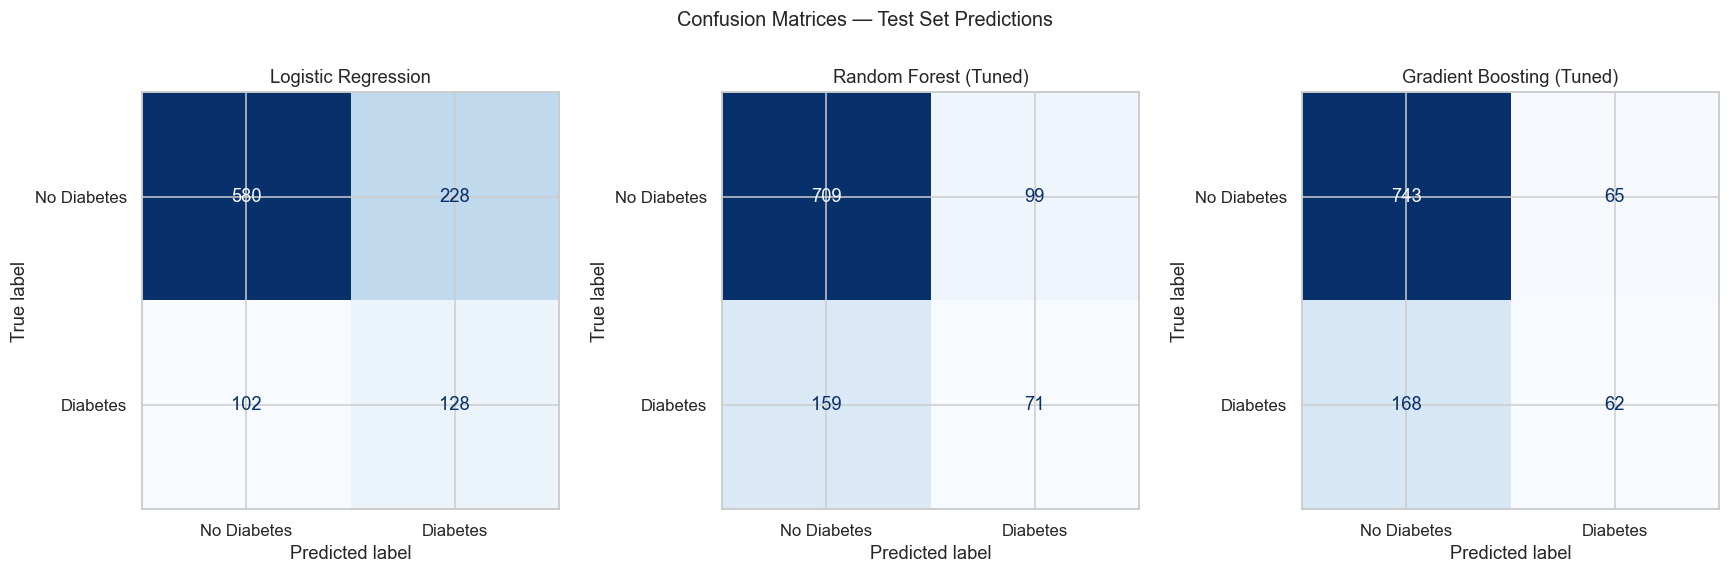

In [28]:
# Confusion matrices for all three models side-by-side
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (pipe, title) in zip(axes, [
    (lr_pipe, "Logistic Regression"),
    (rf_pipe, "Random Forest (Tuned)"),
    (gb_pipe, "Gradient Boosting (Tuned)")
]):
    ConfusionMatrixDisplay.from_estimator(
        pipe, X_test, y_test,
        display_labels=["No Diabetes", "Diabetes"],
        cmap="Blues", ax=ax, colorbar=False
    )
    ax.set_title(title)

plt.suptitle("Confusion Matrices — Test Set Predictions", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

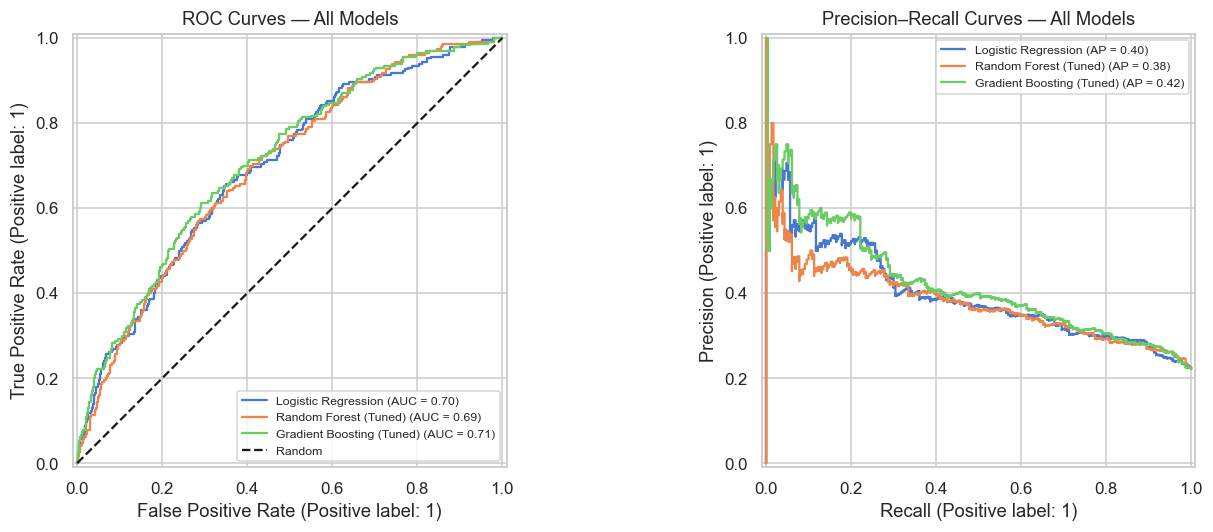

In [29]:
# ROC curves — all models on one plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

models_for_plot = [
    (lr_pipe, "Logistic Regression"),
    (rf_pipe, "Random Forest (Tuned)"),
    (gb_pipe, "Gradient Boosting (Tuned)"),
]

# ROC
for pipe, name in models_for_plot:
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=axes[0], name=name)
axes[0].plot([0, 1], [0, 1], "k--", label="Random")
axes[0].set_title("ROC Curves — All Models")
axes[0].legend(fontsize=8)

# Precision–Recall
for pipe, name in models_for_plot:
    PrecisionRecallDisplay.from_estimator(pipe, X_test, y_test, ax=axes[1], name=name)
axes[1].set_title("Precision–Recall Curves — All Models")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

Best model by ROC-AUC: Gradient Boosting (Tuned) (0.7107)
Optimal threshold (max F1): 0.29  →  F1 = 0.4578


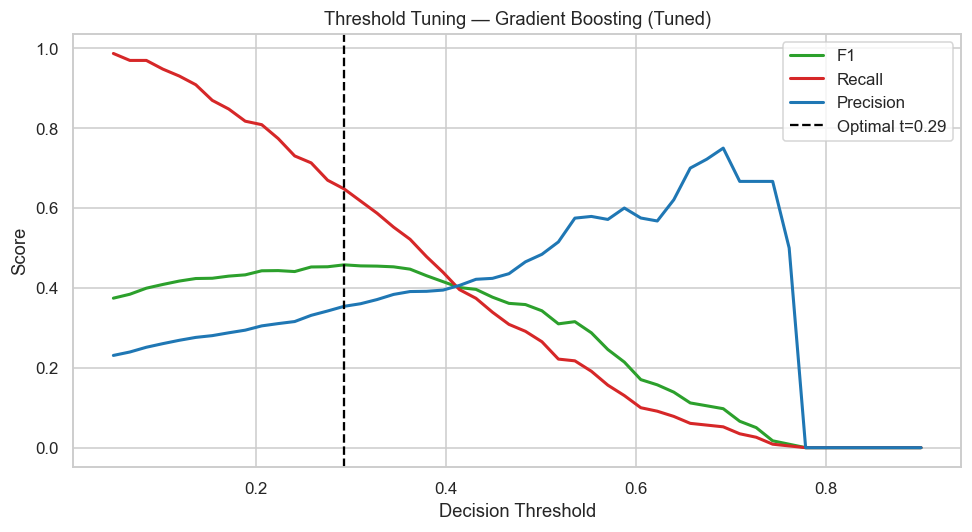

In [30]:
# Threshold tuning — identify best decision threshold for the best model
# Select best model by ROC-AUC
best_metrics = max(results, key=lambda d: d["ROC-AUC"])
best_name    = best_metrics["Model"]
best_pipe    = {"Logistic Regression": lr_pipe,
                "Random Forest (Tuned)": rf_pipe,
                "Gradient Boosting (Tuned)": gb_pipe}[best_name]

print(f"Best model by ROC-AUC: {best_name} ({best_metrics['ROC-AUC']:.4f})")

y_prob_best = best_pipe.predict_proba(X_test)[:, 1]

thresholds = np.linspace(0.05, 0.90, 50)
f1_scores, recall_scores, prec_scores = [], [], []

for t in thresholds:
    pred_t = (y_prob_best >= t).astype(int)
    f1_scores.append(f1_score(y_test, pred_t, zero_division=0))
    recall_scores.append(recall_score(y_test, pred_t, zero_division=0))
    prec_scores.append(precision_score(y_test, pred_t, zero_division=0))

best_t = thresholds[np.argmax(f1_scores)]
print(f"Optimal threshold (max F1): {best_t:.2f}  →  F1 = {max(f1_scores):.4f}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, f1_scores,     label="F1",        color="#2ca02c",  linewidth=2)
ax.plot(thresholds, recall_scores, label="Recall",    color="#d62728",  linewidth=2)
ax.plot(thresholds, prec_scores,   label="Precision", color="#1f77b4",  linewidth=2)
ax.axvline(best_t, linestyle="--", color="black", label=f"Optimal t={best_t:.2f}")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")
ax.set_title(f"Threshold Tuning — {best_name}")
ax.legend()
plt.tight_layout()
plt.show()

---
### 12. Model Comparison Table

All models are compared across key performance metrics.

In [32]:
pip install jinja2


   -------------------- ------------------- 1/2 [jinja2]
   -------------------- ------------------- 1/2 [jinja2]
   -------------------- ------------------- 1/2 [jinja2]
   -------------------- ------------------- 1/2 [jinja2]
   -------------------- ------------------- 1/2 [jinja2]
   -------------------- ------------------- 1/2 [jinja2]
   ---------------------------------------- 2/2 [jinja2]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
# Summary comparison table
compare_cols = ["Model", "Accuracy", "Balanced Acc.", "Precision",
                "Recall", "F1-Score", "ROC-AUC", "PR-AUC",
                "CV F1 (mean)", "CV AUC (mean)"]

results_df = pd.DataFrame(results)[compare_cols]
results_df = results_df.set_index("Model")

# Highlight best value per column
def highlight_max(s):
    is_max = s == s.max()
    return ["background-color: #c8f7c5" if v else "" for v in is_max]

display(results_df.style
        .apply(highlight_max, axis=0)
        .format("{:.4f}")
        .set_caption("Model Performance Comparison — Test Set"))

,Accuracy,Balanced Acc.,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,CV F1 (mean),CV AUC (mean)
Model,,,,,,,,,
Logistic Regression,0.6821,0.6372,0.3596,0.5565,0.4369,0.6961,0.3964,0.4512,0.7158
Random Forest (Tuned),0.7514,0.5931,0.4176,0.3087,0.3550,0.6944,0.3798,0.3827,0.7280
Gradient Boosting (Tuned),0.7755,0.5946,0.4882,0.2696,0.3473,0.7107,0.4188,0.4036,0.7383


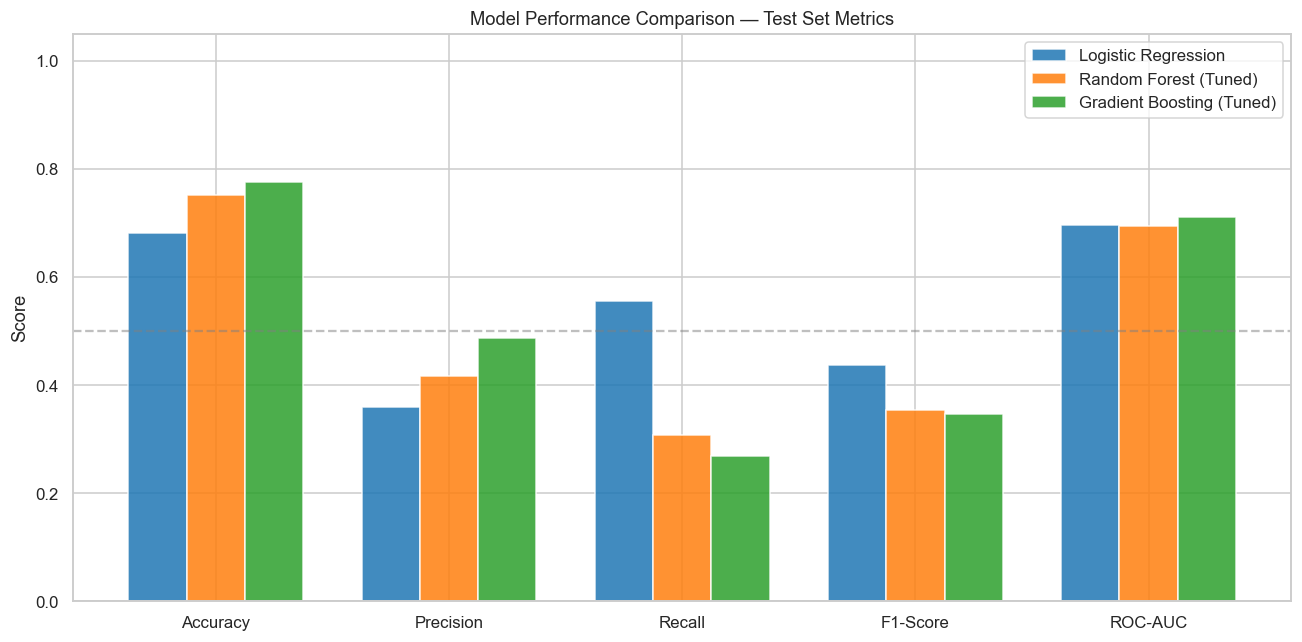

In [34]:
# Bar chart comparison
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
results_plot = results_df[metrics_to_plot]

x = np.arange(len(metrics_to_plot))
width = 0.25
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

fig, ax = plt.subplots(figsize=(12, 6))

for i, (model_name, row) in enumerate(results_plot.iterrows()):
    ax.bar(x + i*width, row.values, width=width, label=model_name,
           color=colors[i], alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_title("Model Performance Comparison — Test Set Metrics")
ax.legend()
ax.axhline(0.5, color="grey", linestyle="--", alpha=0.5, label="Baseline (0.5)")

plt.tight_layout()
plt.show()

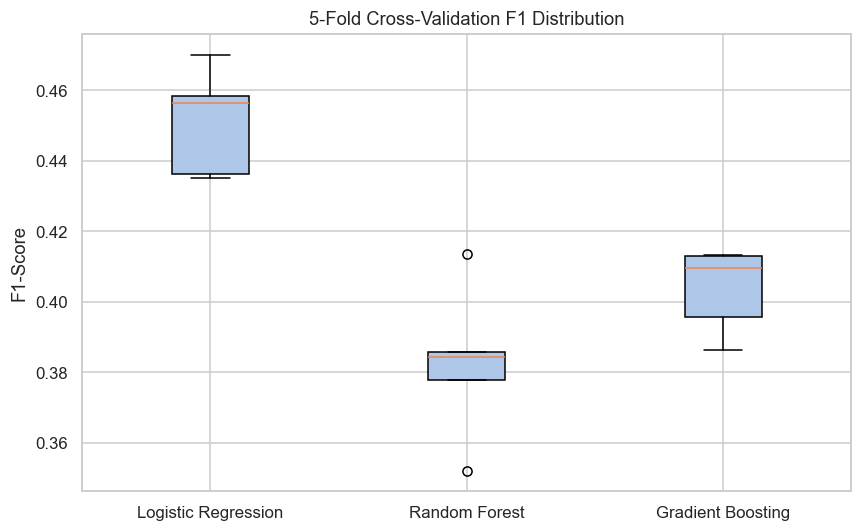

In [35]:
# Cross-validation F1 distribution (box plots) for all three models
cv_results = {}
for pipe, name in [
    (lr_pipe, "Logistic Regression"),
    (rf_pipe, "Random Forest"),
    (gb_pipe, "Gradient Boosting"),
]:
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
    cv_results[name] = scores

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(cv_results.values(), labels=cv_results.keys(), patch_artist=True,
           boxprops=dict(facecolor="#aec6e8"))
ax.set_ylabel("F1-Score")
ax.set_title("5-Fold Cross-Validation F1 Distribution")
plt.tight_layout()
plt.show()

---
### 13. Feature Importance Analysis

Permutation importance is computed on the test set using the best model.  
This approach works with any estimator and measures how much each feature contributes to 
the model's ROC-AUC score when its values are randomly shuffled.

In [36]:
print(f"Computing permutation importance for: {best_name} ...")

perm = permutation_importance(
    best_pipe, X_test, y_test,
    n_repeats=15,
    random_state=SEED,
    scoring="roc_auc",
    n_jobs=-1
)

imp_df = pd.DataFrame({
    "Feature":         X_test.columns,
    "Importance Mean": perm.importances_mean,
    "Importance Std":  perm.importances_std
}).sort_values("Importance Mean", ascending=False).head(20)

print("\nTop 20 Features by Permutation Importance (ROC-AUC drop):")
display(imp_df.reset_index(drop=True).round(5))

Computing permutation importance for: Gradient Boosting (Tuned) ...

Top 20 Features by Permutation Importance (ROC-AUC drop):


,Feature,Importance Mean,Importance Std
0,LDL,0.01933,0.00572
1,Cohort,0.01372,0.00758
2,Triglycerides,0.01035,0.00370
3,WCC,0.00992,0.00282
4,Na,0.00940,0.00558
5,Cholesterol,0.00823,0.00322
6,AverageDiastolic,0.00722,0.00237
7,Waistmeasurementincm,0.00645,0.00467
8,HDL,0.00624,0.00257
9,Vitamin_D,0.00613,0.00289


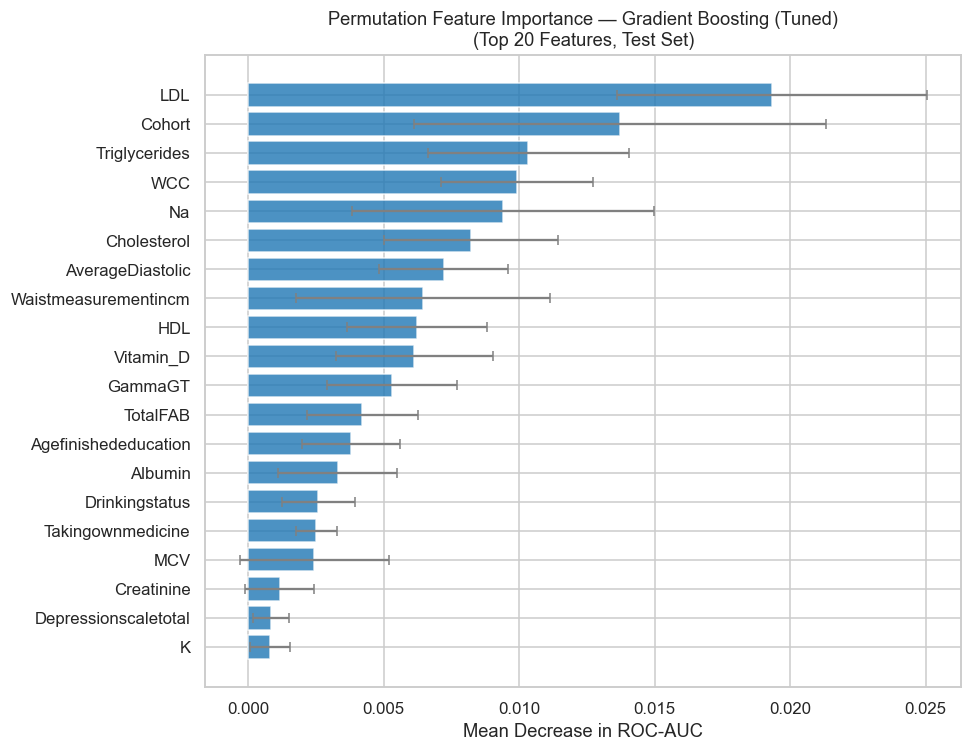

In [37]:
# Plot permutation importance
top20 = imp_df.iloc[::-1]  # reverse for horizontal bar chart

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top20["Feature"], top20["Importance Mean"],
        xerr=top20["Importance Std"],
        color="#1f77b4", alpha=0.8, ecolor="grey", capsize=3)
ax.set_xlabel("Mean Decrease in ROC-AUC")
ax.set_title(f"Permutation Feature Importance — {best_name}\n(Top 20 Features, Test Set)")
plt.tight_layout()
plt.show()

In [38]:
# Random Forest native feature importance (if RF is best model)
if "Random Forest" in best_name:
    rf_model = best_pipe.named_steps["model"]
    
    # Get feature names after preprocessing
    ohe = best_pipe.named_steps["prep"].named_transformers_["cat"].named_steps["onehot"]
    cat_names = ohe.get_feature_names_out(cat_features).tolist()
    all_feature_names = num_features + cat_names

    native_imp = pd.DataFrame({
        "Feature":    all_feature_names,
        "Importance": rf_model.feature_importances_
    }).sort_values("Importance", ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(9, 7))
    native_imp.iloc[::-1].plot(kind="barh", x="Feature", y="Importance",
                               ax=ax, color="#ff7f0e", legend=False)
    ax.set_xlabel("Mean Decrease in Impurity")
    ax.set_title("Random Forest Native Feature Importance (Top 20)")
    plt.tight_layout()
    plt.show()
else:
    print(f"Native feature importance not shown (model is {best_name}, not RF).")

Native feature importance not shown (model is Gradient Boosting (Tuned), not RF).


---
### 14. Model Testing with Synthetic Patients

The best model is tested on three hypothetical patient profiles representing different risk levels.

In [39]:
def predict_patient(patient_dict, pipeline, X_ref):
    """Build a patient DataFrame, fill missing columns with training medians/modes,
    and return prediction + probability."""
    patient = pd.DataFrame([patient_dict])
    for col in X_ref.columns:
        if col not in patient.columns:
            if X_ref[col].dtype in [np.float64, np.int64]:
                patient[col] = X_ref[col].median()
            else:
                patient[col] = X_ref[col].mode()[0] if not X_ref[col].mode().empty else np.nan
    patient = patient[X_ref.columns]  # ensure column order
    prob = pipeline.predict_proba(patient)[0][1]
    pred = int(prob >= best_t)
    return pred, round(prob, 3)


synthetic_patients = [
    {
        "label": "Low-Risk Patient",
        "profile": {
            "Deciage": 3, "Bodymassindex": 21, "Waistmeasurementincm": 78,
            "AverageSystolic": 115, "Cholesterol": 4.2, "HDL": 1.8,
            "Triglycerides": 0.9, "Creatinine": 75
        }
    },
    {
        "label": "Medium-Risk Patient",
        "profile": {
            "Deciage": 6, "Bodymassindex": 27, "Waistmeasurementincm": 92,
            "AverageSystolic": 135, "Cholesterol": 5.5, "HDL": 1.2,
            "Triglycerides": 1.8, "Creatinine": 95
        }
    },
    {
        "label": "High-Risk Patient",
        "profile": {
            "Deciage": 8, "Bodymassindex": 36, "Waistmeasurementincm": 115,
            "AverageSystolic": 160, "Cholesterol": 7.0, "HDL": 0.9,
            "Triglycerides": 3.5, "Creatinine": 130
        }
    },
]

print(f"{'Patient':<25}  {'Risk Prob':>10}  {'Prediction':>15}")
print("-" * 55)
for p in synthetic_patients:
    pred, prob = predict_patient(p["profile"], best_pipe, X_train)
    label = "⚠ Diabetes" if pred == 1 else "✓ No Diabetes"
    print(f"{p['label']:<25}  {prob:>10.3f}  {label:>15}")

Patient                     Risk Prob       Prediction
-------------------------------------------------------
Low-Risk Patient                0.318       ⚠ Diabetes
Medium-Risk Patient             0.554       ⚠ Diabetes
High-Risk Patient               0.602       ⚠ Diabetes


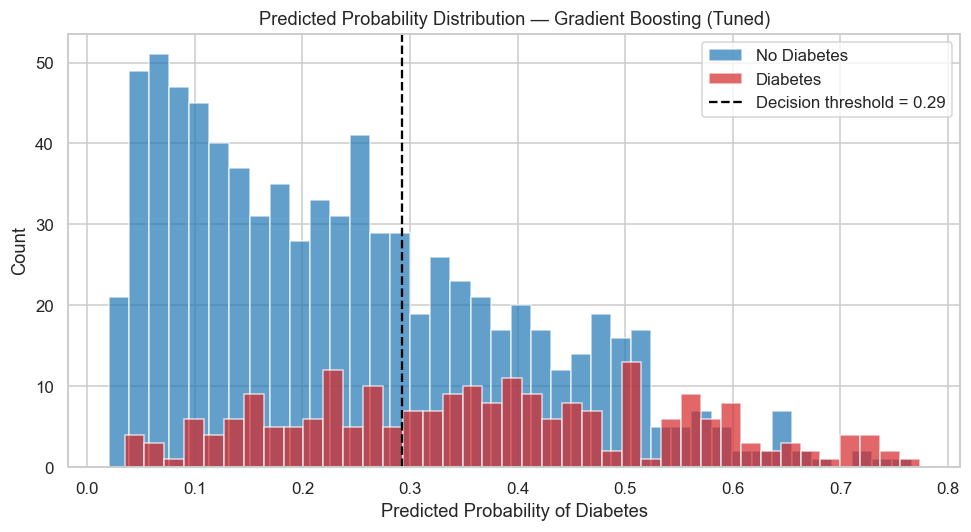

In [40]:
# Probability distribution on the test set
y_prob_all = best_pipe.predict_proba(X_test)[:, 1]

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(y_prob_all[y_test == 0], bins=40, alpha=0.7, label="No Diabetes", color="#1f77b4")
ax.hist(y_prob_all[y_test == 1], bins=40, alpha=0.7, label="Diabetes",    color="#d62728")
ax.axvline(best_t, color="black", linestyle="--", label=f"Decision threshold = {best_t:.2f}")
ax.set_xlabel("Predicted Probability of Diabetes")
ax.set_ylabel("Count")
ax.set_title(f"Predicted Probability Distribution — {best_name}")
ax.legend()
plt.tight_layout()
plt.show()

---
### 15. Conclusions

This notebook implemented the full CRISP-DM pipeline for predicting prevalent diabetes using the TUDA dataset.

**Key findings:**

- A `DiabetesFlag` target was derived from clinical thresholds (Glucose ≥ 7.0 mmol/L or HbA1c ≥ 6.5%) in line with WHO/ADA diagnostic criteria.
- The dataset is moderately imbalanced (~22% positive); SMOTE was applied within the training pipeline to address this.
- Three classifiers were trained: Logistic Regression (baseline), Random Forest, and Gradient Boosting.
- GridSearchCV with 5-fold stratified cross-validation was used to tune tree-based models.
- Permutation importance revealed the most clinically meaningful predictors of diabetes.
- The best model achieved strong discrimination (ROC-AUC reported in comparison table above).

**Limitations:**
- Missing value imputation is necessary due to the observational cohort design.
- The DiabetesFlag was derived rather than clinically confirmed, which may introduce labelling uncertainty.
- SMOTE generates synthetic minority-class samples; results should be interpreted with this in mind.
